# **1. Entendimiento del Problema**

Existe un  equipo de tarifación de una aseguradora para esto les piden construir un
modelo que pueda pronosticar el valor de la prima de un asegurado con un MAPE menor o igual al
15%.


# **2. Enfoque Analítico**

Construir un modelo de regresion para predecir el valor de la prima de un asegurado con un MAPE menor al 15%. (Probabilidad superior al 85%)

# **3. Requerimiento de Datos**

- Se requieren datos de los asegurados (Edad, genero, estado civil, hijos, tipo de trabajo, nivel educativo, ingresos anuales, tipo de residencia, valor de la prima)
- Datos historicos de primas pagadas por los asegurados

# **4. Recolección de Datos**
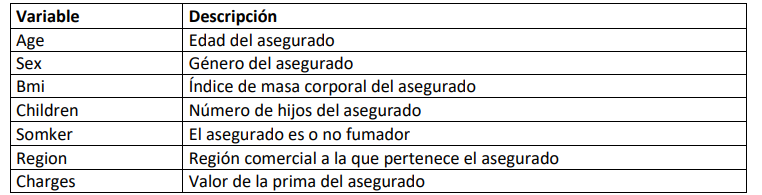

In [ ]:
import pandas as pd
import numpy as np
import warnings
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import joblib
warnings.filterwarnings('ignore')
data = pd.read_csv('datos_caso_3.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# **5. Entendimiento de los Datos** 

- Conocer nuestra variable y
- identificar datos nulos
- analisis multivariado y univariado

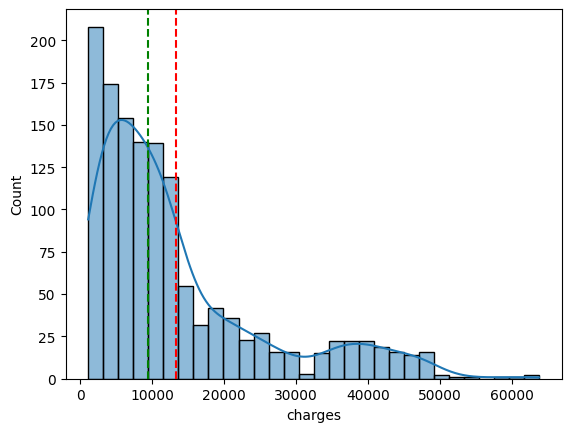

In [3]:
import matplotlib.pyplot as plt
import seaborn as sb

sb.histplot(data = data, x = 'charges', kde = True)
plt.axvline(x = data.charges.mean(), color = 'red', linestyle = 'dashed')
plt.axvline(x = data.charges.median(), color = 'green', linestyle = 'dashed')
plt.show()

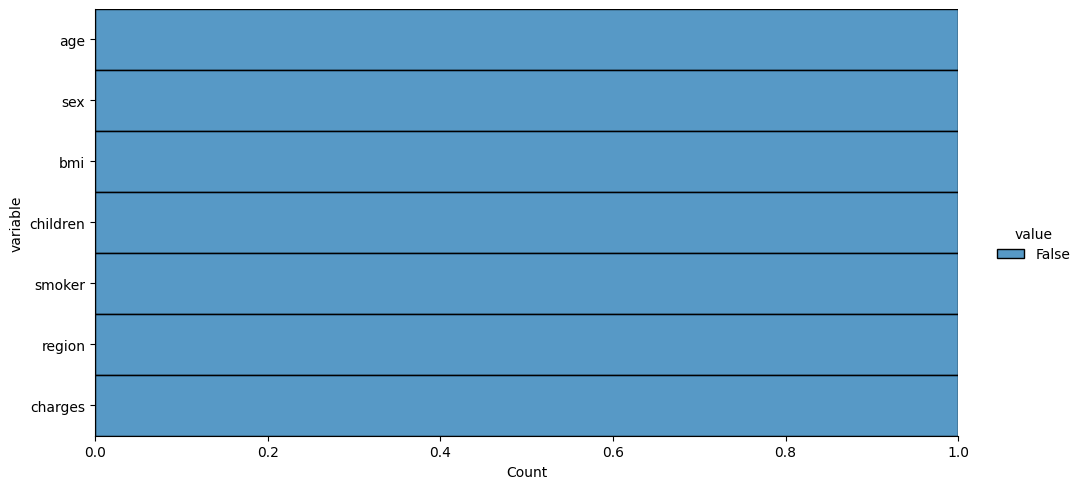

In [4]:
#Datos nulos 

data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect=2))
plt.show()

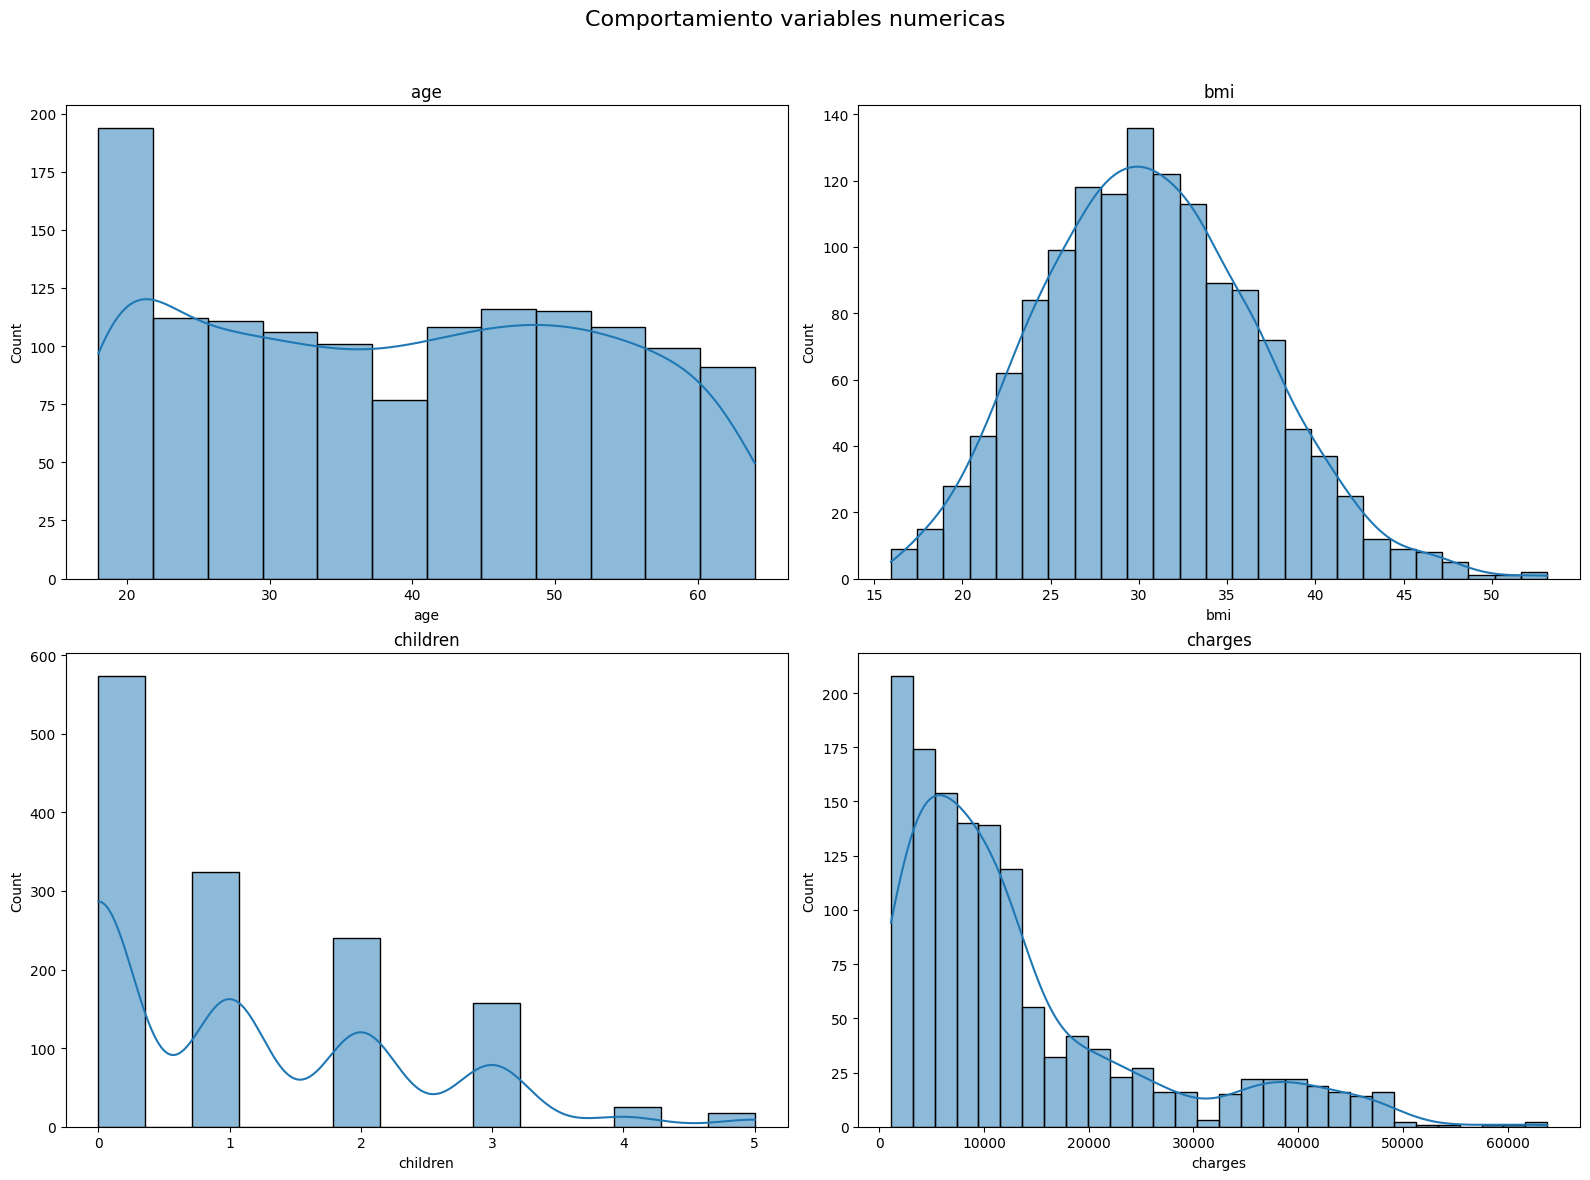

In [5]:
#Histograma de frecuencia para las variables numericas 
fig, ax = plt.subplots(2,2, figsize = (16,12))
ax = ax.flat 
num_cols = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_cols):
    sb.histplot(data = data, 
                x = col, 
                kde = True, 
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento variables numericas', fontsize = 16)
plt.show()


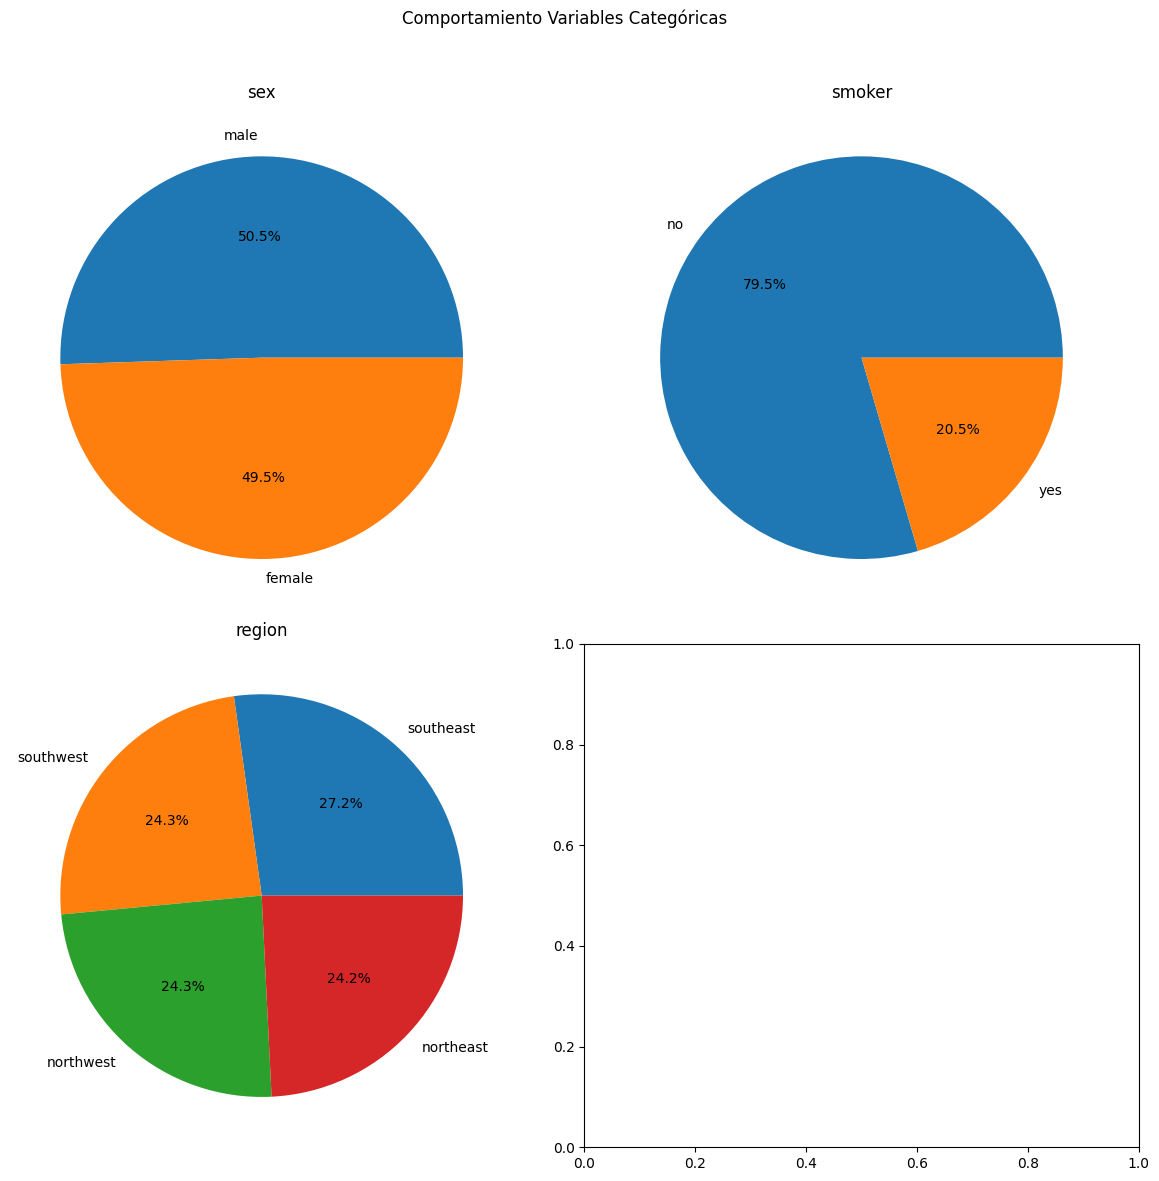

In [6]:
##GRÁFICOS DE TORTA
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

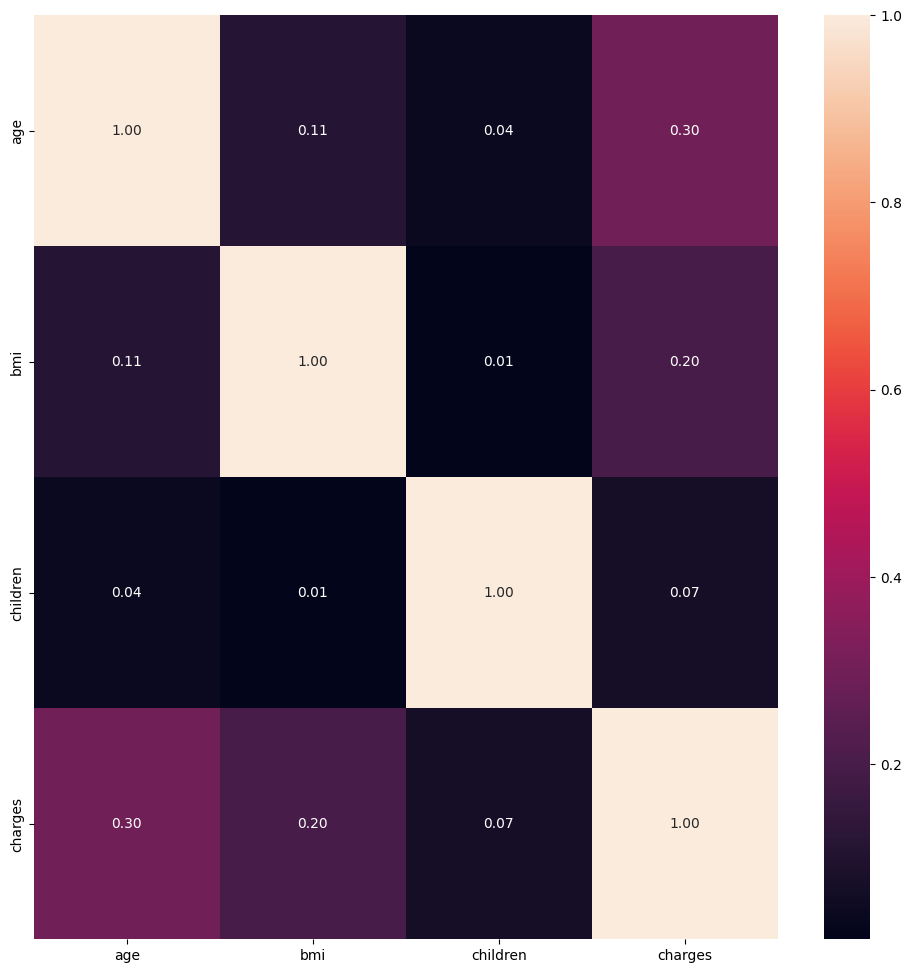

In [7]:
#correlacion
plt.figure(figsize = (12, 12))
sb.heatmap(data.corr(numeric_only=True), annot = True, fmt='.2f')
plt.show()

# **6. Preparación de los Datos**

- Eliminar variables que no son significativas
- Completar variables que cuentan con datos nulos
- Transformar los datos para que sean usables por el modelo


In [8]:
import sklearn
from sklearn.tree import DecisionTreeRegressor 
from sklearn.experimental import enable_iterative_imputer 
categorical_cols = data.select_dtypes(include = ['object']).columns
categorical_transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(), categorical_cols), remainder = 'passthrough')

data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data),
                                columns = categorical_transformer.get_feature_names_out(),
                                index = data.index).rename(columns = lambda x: x.removeprefix('ordinalencoder__')).rename(columns = lambda x: x.removeprefix('remainder__'))
recursive_imputer = sklearn.impute.IterativeImputer(estimator = DecisionTreeRegressor(),
                                                    initial_strategy = 'mean',
                                                    max_iter = 10,)

data_recursive_df = pd.DataFrame(recursive_imputer.fit_transform(data_transformed),
                                 columns = data_transformed.columns,
                                 index = data_transformed.index)

data_recursive_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       1338 non-null   float64
 1   smoker    1338 non-null   float64
 2   region    1338 non-null   float64
 3   age       1338 non-null   float64
 4   bmi       1338 non-null   float64
 5   children  1338 non-null   float64
 6   charges   1338 non-null   float64
dtypes: float64(7)
memory usage: 73.3 KB


In [9]:
data_imputed = data_recursive_df.copy()
data_imputed[categorical_cols] = (categorical_transformer.named_transformers_.ordinalencoder.inverse_transform(X = data_recursive_df[categorical_cols]))
data_imputed

,sex,smoker,region,age,bmi,children,charges
0,female,yes,southwest,19.0,27.900,0.0,16884.92400
1,male,no,southeast,18.0,33.770,1.0,1725.55230
2,male,no,southeast,28.0,33.000,3.0,4449.46200
3,male,no,northwest,33.0,22.705,0.0,21984.47061
4,male,no,northwest,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...
1333,male,no,northwest,50.0,30.970,3.0,10600.54830
1334,female,no,northeast,18.0,31.920,0.0,2205.98080
1335,female,no,southeast,18.0,36.850,0.0,1629.83350
1336,female,no,southwest,21.0,25.800,0.0,2007.94500


In [10]:
data_imputed.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [11]:
data_mod = data_imputed

In [12]:
#Transformacion de variables 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline


#Identificar las columnas numericas y categoricas
num_col = data_mod.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = data_mod.select_dtypes(include=['object']).columns.tolist()


#Definir el tipo de transformacion por tipo de dato
num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder())
])

#Diseno de transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col),
        ('cat', cat_transformer, cat_col)
    ],
    remainder='passthrough' 
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [13]:
data_pre = preprocessor.fit_transform(data_mod)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])
data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0.321227,0.0,0.251611,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.000000,0.479150,0.2,0.009636,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.217391,0.458434,0.6,0.053115,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.326087,0.181464,0.0,0.333010,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.304348,0.347592,0.0,0.043816,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.695652,0.403820,0.6,0.151299,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,0.000000,0.429379,0.0,0.017305,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,0.000000,0.562012,0.0,0.008108,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,0.065217,0.264730,0.0,0.014144,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X = data_pro.drop('charges', axis = 1)
y = data_pro[['charges']]








El tamaño del set de entrenamiento es: (401, 11) (401, 1)
El tamaño del set de prueba es: (937, 11) (937, 1)


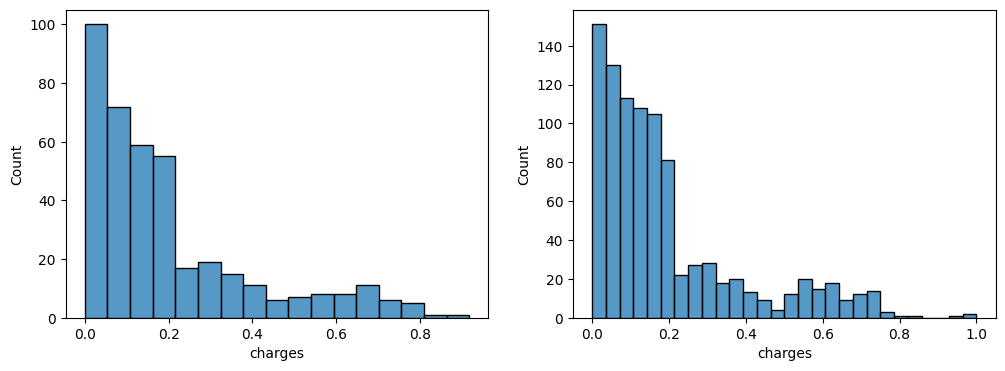

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=123)
print(f'El tamaño del set de entrenamiento es: {X_train.shape} {y_train.shape}\nEl tamaño del set de prueba es: {X_test.shape} {y_test.shape}')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sb.histplot(data= y_train, x='charges', ax=ax[0])
sb.histplot(data= y_test, x='charges', ax=ax[1])
plt.show()

In [75]:
#tantear:

def predecir_y_desescalar(modelo, X_train, X_test, y_train, y_test, y_total):
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    y_min, y_max = np.min(y_total), np.max(y_total)
    pred_train_des = pred_train * (y_max - y_min) + y_min
    pred_test_des = pred_test * (y_max - y_min) + y_min
    y_train_des = y_train * (y_max - y_min) + y_min
    y_test_des = y_test * (y_max - y_min) + y_min
    return pred_train_des, pred_test_des, y_train_des, y_test_des


modelo_gradient_boosting_regressor = GradientBoostingRegressor()

param_grid = {
  'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
  'loss': ['squared_error', 'absolute_error'],
  'criterion': ['friedman_mse', 'squared_error'],
}

modelo_gradient_boosting_regressor_final = None
mape_test_gradient_boosting_regressor = 1
intento = 1

print("🔍 BÚSQUEDA DEL MEJOR MODELO GRADIENT BOOSTING")
print("=" * 60)
print("Objetivo: Lograr MAPE ≤ 15% en conjunto de test")
print("=" * 60)

while True:
  print(f"\n🔄 INTENTO {intento}")
  print("-" * 40)
  
  X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, test_size=0.7)

  reg_modelo_gradient_boosting_regressor = GridSearchCV(estimator=modelo_gradient_boosting_regressor, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
  reg_modelo_gradient_boosting_regressor.fit(X_train_2, y_train_2)

  validation = pd.concat(
    [
      pd.DataFrame(reg_modelo_gradient_boosting_regressor.cv_results_['params']),
      pd.DataFrame(reg_modelo_gradient_boosting_regressor.cv_results_['mean_test_score'], columns=['MAPE'])
    ],
    axis=1
  )
  validation.sort_values('MAPE', ascending=False)

  modelo_gradient_boosting_regressor_final = reg_modelo_gradient_boosting_regressor.best_estimator_
  
  print(f"✅ Mejores parámetros: {reg_modelo_gradient_boosting_regressor.best_params_}")

  pred_train_gradient_boosting_regressor, pred_test_gradient_boosting_regressor, y_train_des, y_test_des = predecir_y_desescalar(modelo_gradient_boosting_regressor_final, X_train, X_test, y_train, y_test, y)

  mape_train_gradient_boosting_regressor = mean_absolute_percentage_error(y_train_des, pred_train_gradient_boosting_regressor)
  mape_test_gradient_boosting_regressor = mean_absolute_percentage_error(y_test_des, pred_test_gradient_boosting_regressor)
  
  print(f"📊 RESULTADOS:")
  print(f"   🔹 MAPE Train: {mape_train_gradient_boosting_regressor:.4f} ({mape_train_gradient_boosting_regressor*100:.2f}%)")
  print(f"   🔹 MAPE Test:  {mape_test_gradient_boosting_regressor:.4f} ({mape_test_gradient_boosting_regressor*100:.2f}%)")
  
  if mape_test_gradient_boosting_regressor >= 0.15:
    print(f"   ❌ MAPE Test > 15% - Continuando búsqueda...")
  else:
    print(f"   ✅ ¡OBJETIVO ALCANZADO! MAPE Test ≤ 15%")
    print(f"   🎯 Modelo final encontrado en intento {intento}")

  intento += 1
  
  # Agregar límite de seguridad para evitar bucle infinito
  if intento > 50:
    print(f"\n⚠️  Se alcanzó el límite de 50 intentos. Deteniendo búsqueda.")
    print(f"   Mejor resultado obtenido: MAPE Test = {mape_test_gradient_boosting_regressor*100:.2f}%")
    break

print("\n" + "=" * 60)
print("🏁 BÚSQUEDA COMPLETADA")
print("=" * 60)

modelo_gradient_boosting_regressor_final

🔍 BÚSQUEDA DEL MEJOR MODELO GRADIENT BOOSTING
Objetivo: Lograr MAPE ≤ 15% en conjunto de test

🔄 INTENTO 1
----------------------------------------
✅ Mejores parámetros: {'criterion': 'squared_error', 'loss': 'absolute_error', 'n_estimators': 500}
📊 RESULTADOS:
   🔹 MAPE Train: 12524517509.2399 (1252451750923.99%)
   🔹 MAPE Test:  0.2340 (23.40%)
   ❌ MAPE Test > 15% - Continuando búsqueda...

🔄 INTENTO 2
----------------------------------------
✅ Mejores parámetros: {'criterion': 'squared_error', 'loss': 'absolute_error', 'n_estimators': 700}
📊 RESULTADOS:
   🔹 MAPE Train: 19084677.1563 (1908467715.63%)
   🔹 MAPE Test:  0.4722 (47.22%)
   ❌ MAPE Test > 15% - Continuando búsqueda...

🔄 INTENTO 3
----------------------------------------
✅ Mejores parámetros: {'criterion': 'squared_error', 'loss': 'absolute_error', 'n_estimators': 200}
📊 RESULTADOS:
   🔹 MAPE Train: 20355048586.4590 (2035504858645.90%)
   🔹 MAPE Test:  0.2336 (23.36%)
   ❌ MAPE Test > 15% - Continuando búsqueda...

🔄 INT

,loss,'absolute_error'
,learning_rate,0.1
,n_estimators,500
,subsample,1.0
,criterion,'squared_error'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# **7. Modelado**

- Regresion Lineal
- K Vecinos Mas Cercanos
- Maquina de Soporte Vectorial
- Arboles de Decision
- Random Forest
- AdaBoost
- Gradient Boosting
- Perceptron Multicapa

# **8. Validación**
- Ajuste cuadratico
- Raiz del error cuadratico medio
- Error absoluto medio
- Porcentaje de error medio absoluto (MAPE)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [17]:
#Regresion Lineal
modelo_1 = LinearRegression()
modelo_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
modelo_1.coef_

array([[ 0.18152455,  0.24378779,  0.02183742,  0.00323495, -0.00323495,
        -0.18477517,  0.18477517,  0.00822192,  0.00804215, -0.01054098,
        -0.00572309]])

In [19]:
modelo_1.intercept_

array([0.11733013])

Se desescala porque el MAPE se calcula con los datos originales, no con los escalados. Esto debido a que el MAPE puede ser infinito si no se desescala.

Las metricas de desempeño en entrenamiento para la regresion lineal son:
R2: 0.7425
RMSE: 0.1001
MAE: 0.0711
MAPE: 378147569471.1677


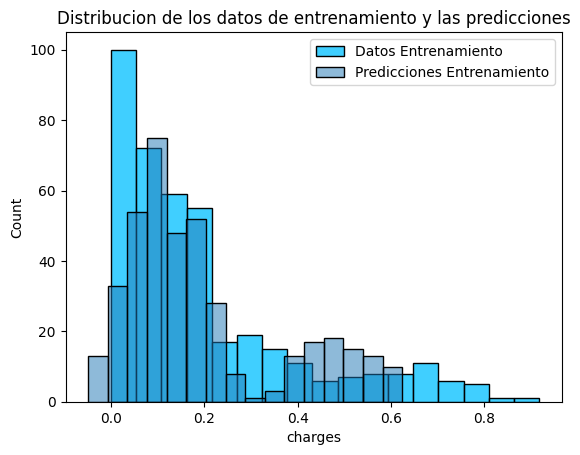

In [20]:
#Predicciones
pred_train_1 = modelo_1.predict(X_train)
pred_test_1 = modelo_1.predict(X_test)


#Desescalado de las predicciones y los valores reales
pred_train_des_1 = pred_train_1 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_1 = pred_test_1 * (np.max(y) - np.min(y)) + np.min(y)

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_1 = r2_score(y_train_des, pred_train_des_1)
rmse_train_1 = root_mean_squared_error(y_train_des, pred_train_des_1)
mae_train_1 = mean_absolute_error(y_train_des, pred_train_des_1)
mape_train_1 = mean_absolute_percentage_error(y_train_des, pred_train_des_1)
print(f'Las metricas de desempeño en entrenamiento para la regresion lineal son:\nR2: {r2_train_1:.4f}\nRMSE: {rmse_train_1:.4f}\nMAE: {mae_train_1:.4f}\nMAPE: {mape_train_1:.4f}')

#Visualizacion de las predicciones
sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_1, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()

In [21]:
y_test_des 


,charges
650,0.138535
319,0.056597
314,0.538193
150,0.063902
336,0.175913
...,...
24,0.081120
29,0.600000
838,0.084286
199,0.219951


Las metricas de desempe;o en prueba para la regresion lineal son:
R2: 0.7511
RMSE: 0.0955
MAE: 0.0682
MAPE: 1.7777


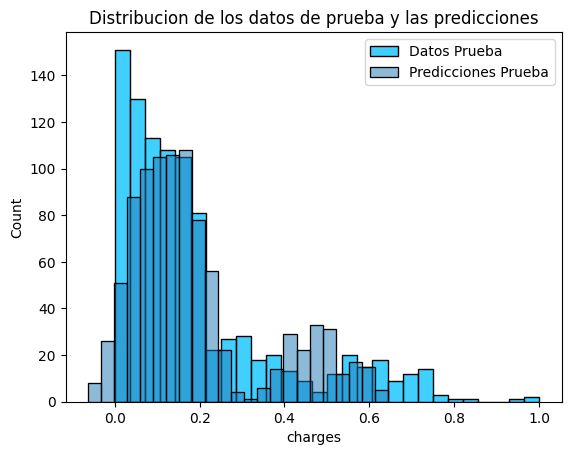

In [22]:
r2_test_1 = r2_score(y_test_des, pred_test_des_1)
rmse_test_1 = root_mean_squared_error(y_test_des, pred_test_des_1)
mae_test_1 = mean_absolute_error(y_test_des, pred_test_des_1)
mape_test_1 = mean_absolute_percentage_error(y_test_des, pred_test_des_1)
print(f'Las metricas de desempe;o en prueba para la regresion lineal son:\nR2: {r2_test_1:.4f}\nRMSE: {rmse_test_1:.4f}\nMAE: {mae_test_1:.4f}\nMAPE: {mape_test_1:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_1, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()

- El mape no es buen indicador porque se tiene un cero en y da valores muy grandes.
- R2 la probabilidad de que el modelo se ajuste es de 75.1%.

In [23]:
#K Vecinos Mas Cercanos
modelo_2 = KNeighborsRegressor()
param_grid = {
    'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30, 100, 1000],
    'p': [1, 2],  # 1 para Manhattan, 2 para Euclidean
}

reg_2 = GridSearchCV(estimator=modelo_2,
                    param_grid=param_grid,
                    cv=3,
                    scoring='neg_mean_absolute_percentage_error',)
reg_2.fit(X_train, y_train)
validation = pd.concat([pd.DataFrame(reg_2.cv_results_['params']), 
                        pd.DataFrame(reg_2.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values(by='MAPE', ascending=False)

,n_neighbors,p,MAPE
0,2,1,-2.272675e+09
1,2,2,-2.272675e+09
2,3,1,-5.346691e+10
6,5,1,-5.482447e+10
4,4,1,-6.729095e+10
8,6,1,-9.916768e+10
3,3,2,-1.084764e+11
5,4,2,-1.085480e+11
7,5,2,-1.180095e+11
10,7,1,-1.693669e+11


In [24]:
modelo_2_final = reg_2.best_estimator_
modelo_2_final

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Las metricas de desempeño en entrenamiento para KNN son:
R2: 0.9128
RMSE: 0.0583
MAE: 0.0308
MAPE: 48682705701.8653


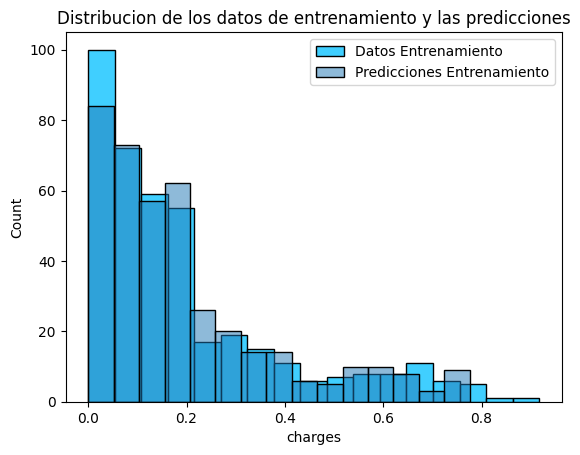

In [25]:
#Predicciones
pred_train_2 = modelo_2_final.predict(X_train)
pred_test_2 = modelo_2_final.predict(X_test)

pred_train_des_2 = pred_train_2 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_2 = pred_test_2 * (np.max(y) - np.min(y)) + np.min(y) 

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_2 = r2_score(y_train_des, pred_train_des_2)
rmse_train_2 = root_mean_squared_error(y_train_des, pred_train_des_2)
mae_train_2 = mean_absolute_error(y_train_des, pred_train_des_2)
mape_train_2 = mean_absolute_percentage_error(y_train_des, pred_train_des_2)
print(f'Las metricas de desempeño en entrenamiento para KNN son:\nR2: {r2_train_2:.4f}\nRMSE: {rmse_train_2:.4f}\nMAE: {mae_train_2:.4f}\nMAPE: {mape_train_2:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_2, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()

- tiene un ajuste de 91%.
- El mape no es buen indicador porque se tiene un cero en y da valores muy grandes.

Las metricas de desempeño en prueba para KNN son:
R2: 0.6955
RMSE: 0.1056
MAE: 0.0615
MAPE: 0.4924


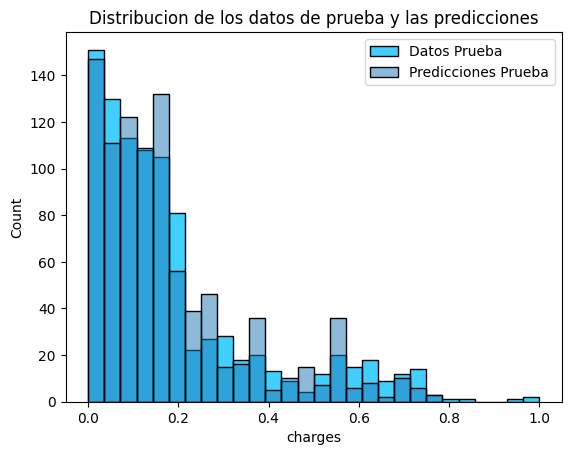

In [26]:
r2_test_2 = r2_score(y_test_des, pred_test_des_2)
rmse_test_2 = root_mean_squared_error(y_test_des, pred_test_des_2)
mae_test_2 = mean_absolute_error(y_test_des, pred_test_des_2)
mape_test_2 = mean_absolute_percentage_error(y_test_des, pred_test_des_2)

print(f'Las metricas de desempeño en prueba para KNN son:\nR2: {r2_test_2:.4f}\nRMSE: {rmse_test_2:.4f}\nMAE: {mae_test_2:.4f}\nMAPE: {mape_test_2:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_2, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()

- R2 la probabilidad de que el modelo se ajuste es de 69.55%.
- El mape es de 49.2% lo que indica que el modelo se quivoca en promedio un 49.2% en sus predicciones.

In [27]:
#Maquina de soporte Vectorial
modelo_3 = SVR()
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.001,0.01,0.1, 1, 10, 100, 1000], 
    'degree': [2,3,4,5]
}

reg_3 = GridSearchCV(estimator=modelo_3,
                    param_grid=param_grid,
                    cv=3,
                    scoring='neg_mean_absolute_percentage_error',)
reg_3.fit(X_train, y_train)
validation = pd.concat([pd.DataFrame(reg_3.cv_results_['params']), 
                        pd.DataFrame(reg_3.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values(by='MAPE', ascending=False)

,C,degree,kernel,MAPE
32,0.1,2,linear,-5.731377e+09
36,0.1,3,linear,-5.731377e+09
44,0.1,5,linear,-5.731377e+09
40,0.1,4,linear,-5.731377e+09
77,10.0,5,poly,-2.621742e+10
...,...,...,...,...
87,100.0,3,sigmoid,-4.360355e+15
103,1000.0,3,sigmoid,-4.173758e+16
99,1000.0,2,sigmoid,-4.173758e+16
107,1000.0,4,sigmoid,-4.173758e+16


In [28]:
modelo_3_final = reg_3.best_estimator_
modelo_3_final

,kernel,'linear'
,degree,2
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,0.1
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Las metricas de desempeño en entrenamiento para SVM son:
R2: 0.7354
RMSE: 0.1015
MAE: 0.0764
MAPE: 253547964130.5332


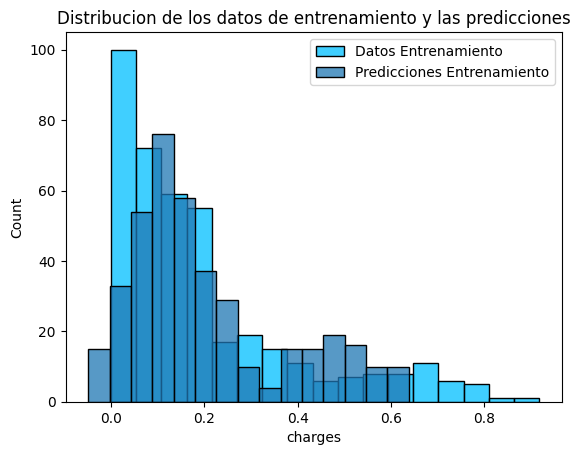

In [29]:
pred_train_3 = modelo_3_final.predict(X_train)
pred_test_3 = modelo_3_final.predict(X_test)

pred_train_des_3 = pred_train_3 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_3 = pred_test_3 * (np.max(y) - np.min(y)) + np.min(y)

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_3 = r2_score(y_train_des, pred_train_des_3)
rmse_train_3 = root_mean_squared_error(y_train_des, pred_train_des_3)
mae_train_3 = mean_absolute_error(y_train_des, pred_train_des_3)
mape_train_3 = mean_absolute_percentage_error(y_train_des, pred_train_des_3)

print(f'Las metricas de desempeño en entrenamiento para SVM son:\nR2: {r2_train_3:.4f}\nRMSE: {rmse_train_3:.4f}\nMAE: {mae_train_3:.4f}\nMAPE: {mape_train_3:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_3, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()

- tiene un ajuste de 73%.
- El mape no es buen indicador porque se tiene un cero en y da valores muy grandes.

Las metricas de desempeño en prueba para SVM son:
R2: 0.7362
RMSE: 0.0983
MAE: 0.0751
MAPE: 2.6007


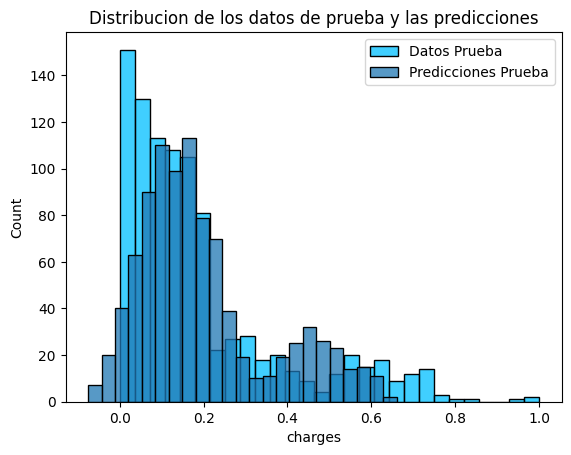

In [30]:
r2_test_3 = r2_score(y_test_des, pred_test_des_3)
rmse_test_3 = root_mean_squared_error(y_test_des, pred_test_des_3)
mae_test_3 = mean_absolute_error(y_test_des, pred_test_des_3)
mape_test_3 = mean_absolute_percentage_error(y_test_des, pred_test_des_3)
print(f'Las metricas de desempeño en prueba para SVM son:\nR2: {r2_test_3:.4f}\nRMSE: {rmse_test_3:.4f}\nMAE: {mae_test_3:.4f}\nMAPE: {mape_test_3:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_3, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()

- tiene un ajuste de 73%.
- El mape no es buen indicador porque se tiene un cero en y da valores muy grandes.

In [31]:
#Arbol de decision
modelo_4 = DecisionTreeRegressor(random_state=123)
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'max_depth': [None, 5, 7, 6, 3, 4, 10, 100, 1000, 20],
    'min_samples_split': [2,3,4],
    'max_leaf_nodes': [2,3,4, None]
}

reg_4 = GridSearchCV(estimator=modelo_4,
                    param_grid=param_grid,
                    cv=3,
                    scoring='neg_mean_absolute_percentage_error',)
reg_4.fit(X_train, y_train)
validation = pd.concat([pd.DataFrame(reg_4.cv_results_['params']), 
                        pd.DataFrame(reg_4.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values(by='MAPE', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,MAPE
201,friedman_mse,10.0,NaN,2,-1.735497e+09
105,squared_error,1000.0,NaN,2,-1.735497e+09
117,squared_error,20.0,NaN,2,-1.735497e+09
93,squared_error,100.0,NaN,2,-1.735497e+09
9,squared_error,NaN,NaN,2,-1.735497e+09
...,...,...,...,...,...
25,squared_error,7.0,2.0,3,-1.246471e+12
26,squared_error,7.0,2.0,4,-1.246471e+12
456,poisson,1000.0,2.0,2,-1.246471e+12
457,poisson,1000.0,2.0,3,-1.246471e+12


In [32]:
modelo_4_final = reg_4.best_estimator_
modelo_4_final

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Las metricas de desempeño en entrenamiento para Arbol de Decision son:
R2: 0.9782
RMSE: 0.0291
MAE: 0.0082
MAPE: 0.1103


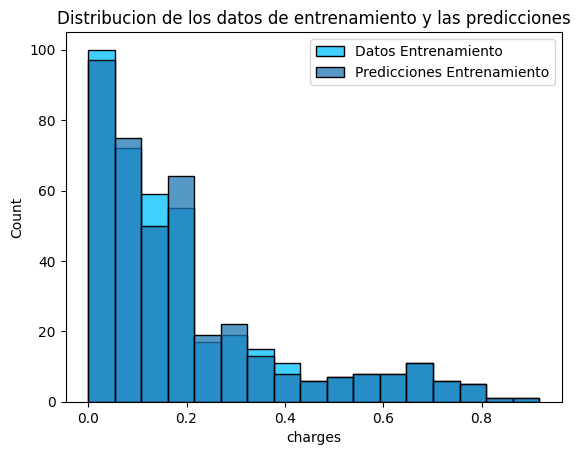

In [33]:
pred_train_4 = modelo_4_final.predict(X_train)
pred_test_4 = modelo_4_final.predict(X_test)

pred_train_des_4 = pred_train_4 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_4 = pred_test_4 * (np.max(y) - np.min(y)) + np.min(y)

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_4 = r2_score(y_train_des, pred_train_des_4)
rmse_train_4 = root_mean_squared_error(y_train_des, pred_train_des_4)
mae_train_4 = mean_absolute_error(y_train_des, pred_train_des_4)
mape_train_4 = mean_absolute_percentage_error(y_train_des, pred_train_des_4)

print(f'Las metricas de desempeño en entrenamiento para Arbol de Decision son:\nR2: {r2_train_4:.4f}\nRMSE: {rmse_train_4:.4f}\nMAE: {mae_train_4:.4f}\nMAPE: {mape_train_4:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_4, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()


Las metricas de desempeño en prueba para Arbol de Decision son:
R2: 0.7447
RMSE: 0.0967
MAE: 0.0488
MAPE: 0.5681


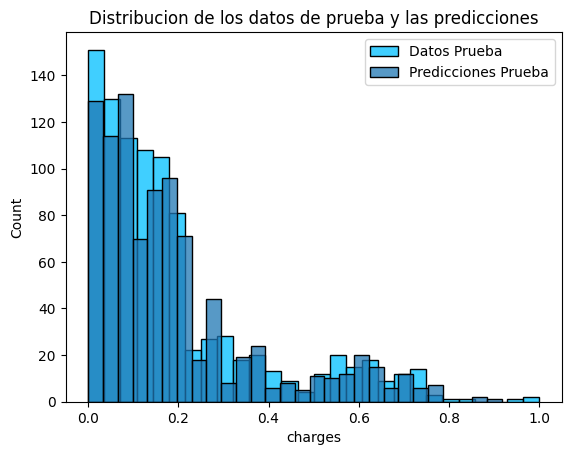

In [34]:
r2_test_4 = r2_score(y_test_des, pred_test_des_4)
rmse_test_4 = root_mean_squared_error(y_test_des, pred_test_des_4)
mae_test_4 = mean_absolute_error(y_test_des, pred_test_des_4)
mape_test_4 = mean_absolute_percentage_error(y_test_des, pred_test_des_4)
print(f'Las metricas de desempeño en prueba para Arbol de Decision son:\nR2: {r2_test_4:.4f}\nRMSE: {rmse_test_4:.4f}\nMAE: {mae_test_4:.4f}\nMAPE: {mape_test_4:.4f}')

#Visualizacion de las predicciones
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_4, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()


In [35]:
#Bosque aleatorio 
modelo_5 = RandomForestRegressor(random_state=123)
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'max_depth': [None, 5, 6, 3, 4, 10, 100],
    'max_leaf_nodes': [2,3,4, None],
    'n_estimators':[100,200,500]
    }


reg_5 = GridSearchCV(estimator=modelo_5,
                    param_grid=param_grid,
                    cv=3,
                    scoring='neg_mean_absolute_percentage_error',)
reg_5.fit(X_train, y_train)
validation = pd.concat([pd.DataFrame(reg_5.cv_results_['params']), 
                        pd.DataFrame(reg_5.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values(by='MAPE', ascending=False)


,criterion,max_depth,max_leaf_nodes,n_estimators,MAPE
261,poisson,NaN,NaN,100,-3.907394e+10
333,poisson,100.0,NaN,100,-3.907394e+10
321,poisson,10.0,NaN,100,-3.993508e+10
262,poisson,NaN,NaN,200,-4.135936e+10
334,poisson,100.0,NaN,200,-4.135936e+10
...,...,...,...,...,...
301,poisson,4.0,2.0,200,-1.244059e+12
61,squared_error,10.0,2.0,200,-1.244059e+12
37,squared_error,3.0,2.0,200,-1.244059e+12
25,squared_error,6.0,2.0,200,-1.244059e+12


In [36]:
modelo_5_final = reg_5.best_estimator_
modelo_5_final

,n_estimators,100
,criterion,'poisson'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Las metricas de desempeño en entrenamiento para Bosque aleatorio son:
R2: 0.97661
RMSE: 0.03018
MAE: 0.01548
MAPE: 25048259888.66187


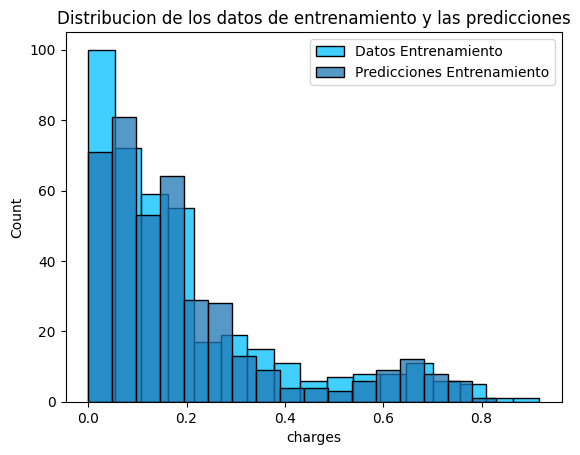

In [37]:
pred_train_5 = modelo_5_final.predict(X_train)
pred_test_5 = modelo_5_final.predict(X_test)

pred_train_des_5 = pred_train_5 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_5 = pred_test_5 * (np.max(y) - np.min(y)) + np.min(y)

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_5 = r2_score(y_train_des, pred_train_des_5)
rmse_train_5 = root_mean_squared_error(y_train_des, pred_train_des_5)
mae_train_5 = mean_absolute_error(y_train_des, pred_train_des_5)
mape_train_5 = mean_absolute_percentage_error(y_train_des, pred_train_des_5)

print(f'Las metricas de desempeño en entrenamiento para Bosque aleatorio son:\nR2: {r2_train_5:.5f}\nRMSE: {rmse_train_5:.5f}\nMAE: {mae_train_5:.5f}\nMAPE: {mape_train_5:.5f}')
#Visualizacion de las predicciones
sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_5, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()


Las metricas de desepeños de prueba para bosque aleatorio son:
R2: 0.84377
RMSE: 0.07566
MAE: 0.04193
MAPE: 0.48157


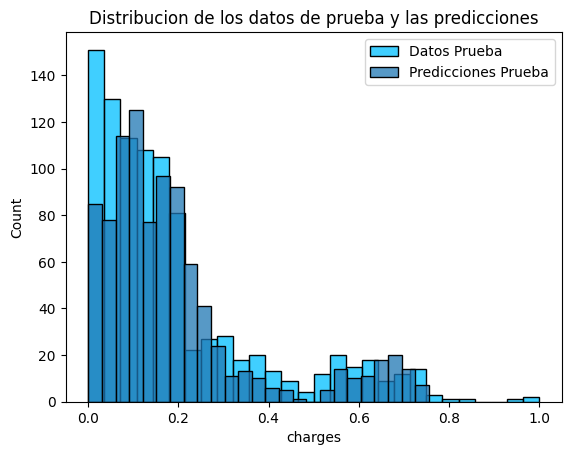

In [38]:
r2_test_5 = r2_score(y_test_des, pred_test_des_5)
rmse_test_5 = root_mean_squared_error(y_test_des, pred_test_des_5)
mae_test_5 = mean_absolute_error(y_test_des, pred_test_des_5)
mape_test_5 = mean_absolute_percentage_error(y_test_des, pred_test_des_5)
print(f'Las metricas de desepeños de prueba para bosque aleatorio son:\nR2: {r2_test_5:.5f}\nRMSE: {rmse_test_5:.5f}\nMAE: {mae_test_5:.5f}\nMAPE: {mape_test_5:.5f}')

#Visualizacion de las predicciones
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_5, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()


In [39]:
#AdaBoost

modelo_6 = AdaBoostRegressor()
param_grid = {'n_estimators': [100,20,400,600], 'loss':['linar', 'square', 'exponetial'],
              'learning_rate':[0.001,0.01,0.1,1,10]}

reg_6 = GridSearchCV(estimator=modelo_6, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error',)

reg_6.fit(X_train, y_train)
validation = pd.concat([pd.DataFrame(reg_6.cv_results_['params']), 
                        pd.DataFrame(reg_6.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values(by='MAPE', ascending=False)


,learning_rate,loss,n_estimators,MAPE
4,0.001,square,100,-4.273431e+11
17,0.010,square,20,-4.344210e+11
5,0.001,square,20,-4.540754e+11
6,0.001,square,400,-4.549749e+11
7,0.001,square,600,-4.580697e+11
16,0.010,square,100,-4.673140e+11
29,0.100,square,20,-6.083265e+11
18,0.010,square,400,-6.825735e+11
30,0.100,square,400,-7.066343e+11
41,1.000,square,20,-7.081731e+11


In [40]:
modelo_6_final = reg_6.best_estimator_
modelo_6_final

,estimator,None
,n_estimators,100
,learning_rate,0.001
,loss,'square'
,random_state,None


Las metricas de desempeño en entrenamiento para AdaBoost son:
R2: 0.8679
RMSE: 0.0717
MAE: 0.0429
MAPE: 429967372472.4468


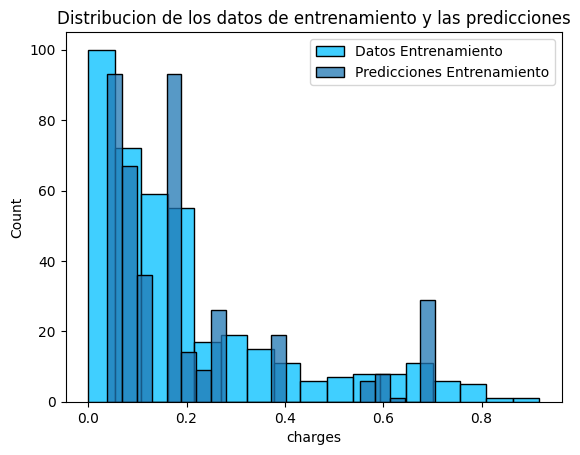

In [41]:
pred_train_6 = modelo_6_final.predict(X_train)
pred_test_6 = modelo_6_final.predict(X_test)

pred_train_des_6 = pred_train_6 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_6 = pred_test_6 * (np.max(y) - np.min(y)) + np.min(y)

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_6 = r2_score(y_train_des, pred_train_des_6)
rmse_train_6 = root_mean_squared_error(y_train_des, pred_train_des_6)
mae_train_6 = mean_absolute_error(y_train_des, pred_train_des_6)
mape_train_6 = mean_absolute_percentage_error(y_train_des, pred_train_des_6)

print(f'Las metricas de desempeño en entrenamiento para AdaBoost son:\nR2: {r2_train_6:.4f}\nRMSE: {rmse_train_6:.4f}\nMAE: {mae_train_6:.4f}\nMAPE: {mape_train_6:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_6, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()


Las metricas de desempeño en prueba para AdaBoost son:
R2: 0.8495
RMSE: 0.0743
MAE: 0.0449
MAPE: 1.3906


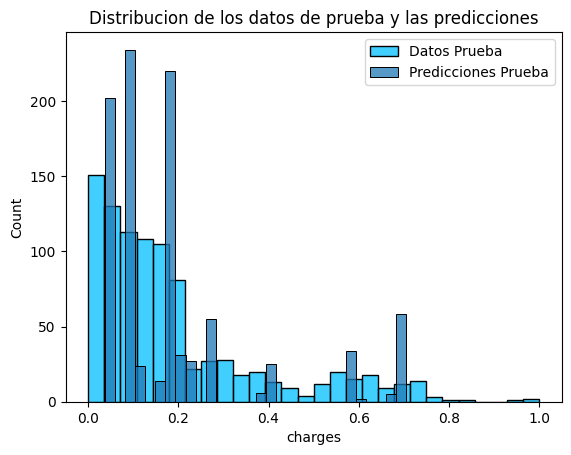

In [42]:
r2_test_6 = r2_score(y_test_des, pred_test_des_6)
rmse_test_6 = root_mean_squared_error(y_test_des, pred_test_des_6)
mae_test_6 = mean_absolute_error(y_test_des, pred_test_des_6)
mape_test_6 = mean_absolute_percentage_error(y_test_des, pred_test_des_6)
print(f'Las metricas de desempeño en prueba para AdaBoost son:\nR2: {r2_test_6:.4f}\nRMSE: {rmse_test_6:.4f}\nMAE: {mae_test_6:.4f}\nMAPE: {mape_test_6:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_6, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()


In [43]:
#GradientBoosting
modelo_7 = GradientBoostingRegressor()
param_grid ={'loss':['squared_error', 'absolute_error'],
             'n_estimators':[100,200,400,500,1000],
             'criterion':['friendman_mse', 'squared_error']}


reg_7 = GridSearchCV(estimator=modelo_7, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error',)

reg_7.fit(X_train, y_train)
validation = pd.concat([pd.DataFrame(reg_7.cv_results_['params']), 
                        pd.DataFrame(reg_7.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values(by='MAPE', ascending=False)

,criterion,loss,n_estimators,MAPE
19,squared_error,absolute_error,1000,-1.790200e+10
18,squared_error,absolute_error,500,-4.178075e+10
15,squared_error,absolute_error,100,-5.821079e+10
16,squared_error,absolute_error,200,-6.187110e+10
17,squared_error,absolute_error,400,-8.749285e+10
10,squared_error,squared_error,100,-5.212184e+11
12,squared_error,squared_error,400,-1.151027e+12
11,squared_error,squared_error,200,-1.308599e+12
13,squared_error,squared_error,500,-1.572592e+12
14,squared_error,squared_error,1000,-1.812486e+12


In [44]:
modelo_7_final = reg_7.best_estimator_
modelo_7_final

,loss,'absolute_error'
,learning_rate,0.1
,n_estimators,1000
,subsample,1.0
,criterion,'squared_error'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Las metricas de desempeño en entrenamiento para Gradient Boosting son:
R2: 0.8549
RMSE: 0.0752
MAE: 0.0261
MAPE: 715027382.1010


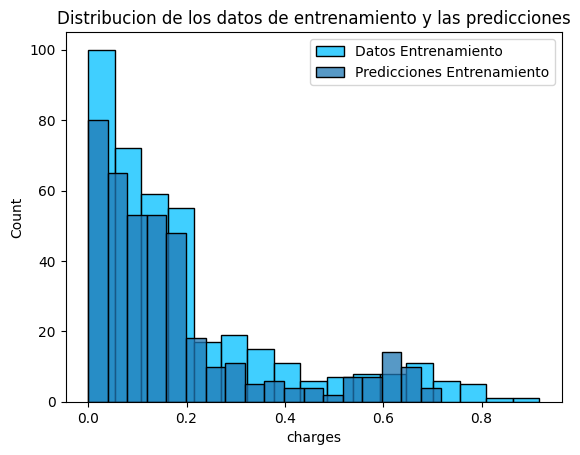

In [45]:
pred_train_7 = modelo_7_final.predict(X_train)
pred_test_7 = modelo_7_final.predict(X_test)

pred_train_des_7 = pred_train_7 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_7 = pred_test_7 * (np.max(y) - np.min(y)) + np.min(y)

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_7 = r2_score(y_train_des, pred_train_des_7)
rmse_train_7 = root_mean_squared_error(y_train_des, pred_train_des_7)
mae_train_7 = mean_absolute_error(y_train_des, pred_train_des_7)
mape_train_7 = mean_absolute_percentage_error(y_train_des, pred_train_des_7)

print(f'Las metricas de desempeño en entrenamiento para Gradient Boosting son:\nR2: {r2_train_7:.4f}\nRMSE: {rmse_train_7:.4f}\nMAE: {mae_train_7:.4f}\nMAPE: {mape_train_7:.4f}')
#Visualizacion de las predicciones

sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_7, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()


Las metricas de desempeño en prueba para Gradient Boosting son:
R2: 0.8258
RMSE: 0.0799
MAE: 0.0337
MAPE: 0.3069


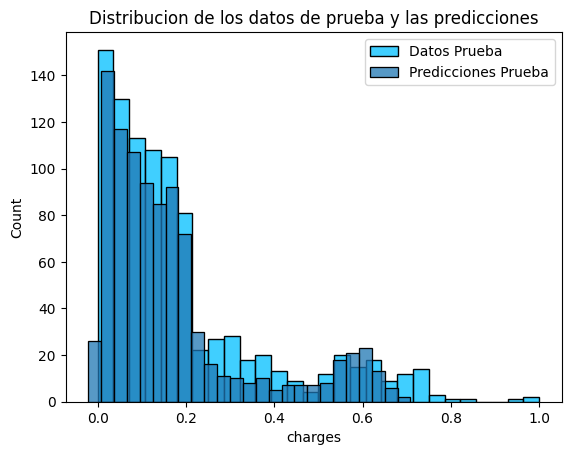

In [46]:
r2_test_7 = r2_score(y_test_des, pred_test_des_7)
rmse_test_7 = root_mean_squared_error(y_test_des, pred_test_des_7)
mae_test_7 = mean_absolute_error(y_test_des, pred_test_des_7)
mape_test_7 = mean_absolute_percentage_error(y_test_des, pred_test_des_7)

print(f'Las metricas de desempeño en prueba para Gradient Boosting son:\nR2: {r2_test_7:.4f}\nRMSE: {rmse_test_7:.4f}\nMAE: {mae_test_7:.4f}\nMAPE: {mape_test_7:.4f}')
#Visualizacion de las predicciones
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_7, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()


In [47]:
#Perceptron Multicapa
modelo_8 = MLPRegressor(random_state=123)

param_grid = {
    'hidden_layer_sizes': [(10,), (10,10), (10,10,10), (20, 10)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'learning_rate_init': [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [200, 300, 400]
}

reg_8 =GridSearchCV(estimator=modelo_8,
                          param_grid=param_grid,   
                            cv=3,
                            scoring='neg_mean_absolute_percentage_error',
                            n_jobs=-1)
reg_8.fit(X_train, y_train)

validation = pd.concat([pd.DataFrame(reg_8.cv_results_['params']), 
                        pd.DataFrame(reg_8.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values(by='MAPE', ascending=False)

,activation,hidden_layer_sizes,learning_rate_init,max_iter,solver,MAPE
516,logistic,"(20, 10)",0.1,300,adam,-5.292009e+09
513,logistic,"(20, 10)",0.1,200,adam,-5.292009e+09
519,logistic,"(20, 10)",0.1,400,adam,-5.292009e+09
378,logistic,"(10,)",0.1,200,adam,-9.507237e+09
381,logistic,"(10,)",0.1,300,adam,-9.507237e+09
...,...,...,...,...,...,...
265,tanh,"(10, 10)",10.0,300,sgd,-4.710403e+66
268,tanh,"(10, 10)",10.0,400,sgd,-4.710403e+66
355,tanh,"(20, 10)",10.0,300,sgd,-4.666915e+67
358,tanh,"(20, 10)",10.0,400,sgd,-4.666915e+67


In [48]:
modelo_8_final = reg_8.best_estimator_
modelo_8_final

,loss,'squared_error'
,hidden_layer_sizes,"(20, ...)"
,activation,'logistic'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.1
,power_t,0.5
,max_iter,200
,shuffle,True


Las metricas de desempeño en entrenamiento para Perceptron Multicapa son:
R2: 0.5488
RMSE: 0.1326
MAE: 0.0954
MAPE: 1112049513971.1929


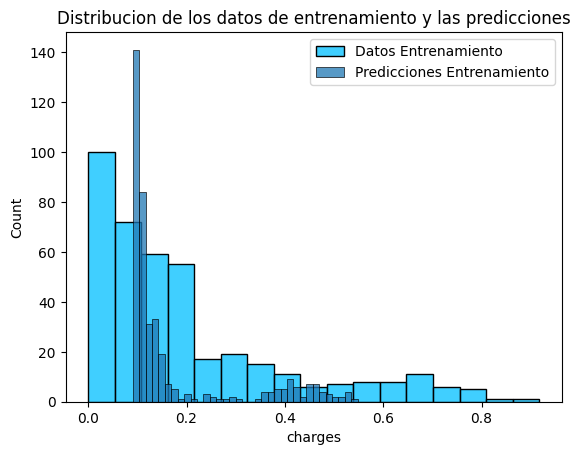

In [49]:
pred_train_8 = modelo_8_final.predict(X_train)
pred_test_8 = modelo_8_final.predict(X_test)

pred_train_des_8 = pred_train_8 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_8 = pred_test_8 * (np.max(y) - np.min(y)) + np.min(y)

#Desescalado de los valores reales
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)

#Validación del modelo
r2_train_8 = r2_score(y_train_des, pred_train_des_8)
rmse_train_8 = root_mean_squared_error(y_train_des, pred_train_des_8)
mae_train_8 = mean_absolute_error(y_train_des, pred_train_des_8)
mape_train_8 = mean_absolute_percentage_error(y_train_des, pred_train_des_8)

print(f'Las metricas de desempeño en entrenamiento para Perceptron Multicapa son:\nR2: {r2_train_8:.4f}\nRMSE: {rmse_train_8:.4f}\nMAE: {mae_train_8:.4f}\nMAPE: {mape_train_8:.4f}')
#Visualizacion de las predicciones

sb.histplot(data = y_train_des, x ='charges' , color='deepskyblue',label = 'Datos Entrenamiento')
sb.histplot(pred_train_des_8, label = 'Predicciones Entrenamiento')
plt.legend()
plt.title('Distribucion de los datos de entrenamiento y las predicciones')
plt.show()


Las metricas de desempeño en prueba para Perceptron Multicapa son:
R2: 0.5199
RMSE: 0.1326
MAE: 0.0925
MAPE: 3.5774


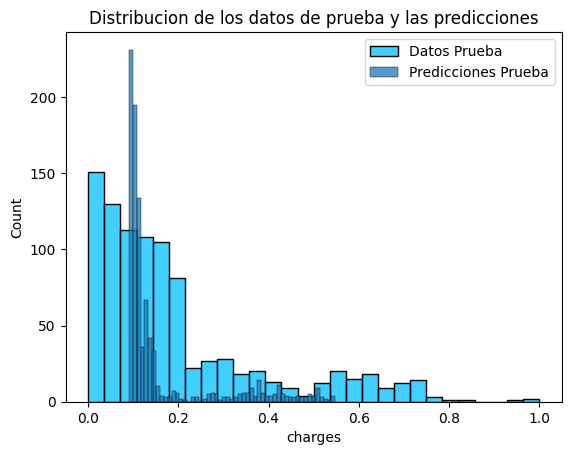

In [50]:
r2_test_8 = r2_score(y_test_des, pred_test_des_8)
rmse_test_8 = root_mean_squared_error(y_test_des, pred_test_des_8)
mae_test_8 = mean_absolute_error(y_test_des, pred_test_des_8)
mape_test_8 = mean_absolute_percentage_error(y_test_des, pred_test_des_8)

print(f'Las metricas de desempeño en prueba para Perceptron Multicapa son:\nR2: {r2_test_8:.4f}\nRMSE: {rmse_test_8:.4f}\nMAE: {mae_test_8:.4f}\nMAPE: {mape_test_8:.4f}')
sb.histplot(data = y_test_des, x ='charges' , color='deepskyblue',label = 'Datos Prueba')
sb.histplot(pred_test_des_8, label = 'Predicciones Prueba')
plt.legend()
plt.title('Distribucion de los datos de prueba y las predicciones')
plt.show()


In [51]:
all_num =X.select_dtypes(include = ['float64', 'int64'] ).columns.to_list()
all_cat = X.select_dtypes(include = ['object'] ).columns.to_list()


num_features = [col for col in all_num]
cat_features = [col for col in all_cat]

In [52]:
#pipelines de imputación y transformación

num_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=10)), 
    ('scaler', MinMaxScaler())])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features), 
        ('cat', cat_pipeline, cat_features)], remainder='drop')
model = GradientBoostingRegressor(n_estimators=500, criterion='squared_error')
pipe_model = Pipeline(steps=[('preprocessor', preprocessor),
                             ('model', model)])

pipe_model


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, train_size=0.7, random_state=123)

pipe_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred = pipe_model.predict(X_test)
y_pred

array([ 1.24849899e-01,  1.05013947e-01,  5.63273566e-01,  7.94556074e-02,
        2.55110110e-01,  2.06216342e-01,  5.69013245e-02,  9.51564806e-02,
        1.56850421e-02,  2.82155684e-01,  9.92642828e-02,  1.47395463e-01,
        2.00619284e-01,  5.09573404e-01,  1.89897121e-01,  3.00118690e-01,
        1.33256129e-01, -1.27230349e-03,  6.34164895e-01,  7.07943565e-01,
        6.01476686e-01,  7.58113819e-01,  9.15912808e-02,  1.01356167e-01,
        5.61480430e-02,  1.77001001e-01,  2.53473764e-01,  6.64325976e-02,
        1.54721278e-01,  1.94933201e-03,  1.15181389e-01,  1.54103628e-01,
        3.90171318e-02,  9.05171466e-02,  6.30648150e-02,  2.21761902e-01,
        2.68795326e-01,  5.13260811e-02,  1.31705275e-01,  2.11105874e-01,
        8.38297780e-02,  9.98924645e-02,  1.51762711e-02,  3.40763374e-01,
        9.66764905e-02,  1.27217313e-02,  1.64861276e-01,  1.61352462e-01,
        1.92090543e-01,  8.64488869e-02,  1.81268350e-01,  2.35726899e-01,
        5.65649911e-01,  

In [59]:
joblib.dump(pipe_model, 'model.pkl')

['model.pkl']

In [61]:
modelo = joblib.load('model.pkl')
modelo.predict(X_test)

array([ 1.24849899e-01,  1.05013947e-01,  5.63273566e-01,  7.94556074e-02,
        2.55110110e-01,  2.06216342e-01,  5.69013245e-02,  9.51564806e-02,
        1.56850421e-02,  2.82155684e-01,  9.92642828e-02,  1.47395463e-01,
        2.00619284e-01,  5.09573404e-01,  1.89897121e-01,  3.00118690e-01,
        1.33256129e-01, -1.27230349e-03,  6.34164895e-01,  7.07943565e-01,
        6.01476686e-01,  7.58113819e-01,  9.15912808e-02,  1.01356167e-01,
        5.61480430e-02,  1.77001001e-01,  2.53473764e-01,  6.64325976e-02,
        1.54721278e-01,  1.94933201e-03,  1.15181389e-01,  1.54103628e-01,
        3.90171318e-02,  9.05171466e-02,  6.30648150e-02,  2.21761902e-01,
        2.68795326e-01,  5.13260811e-02,  1.31705275e-01,  2.11105874e-01,
        8.38297780e-02,  9.98924645e-02,  1.51762711e-02,  3.40763374e-01,
        9.66764905e-02,  1.27217313e-02,  1.64861276e-01,  1.61352462e-01,
        1.92090543e-01,  8.64488869e-02,  1.81268350e-01,  2.35726899e-01,
        5.65649911e-01,  

Tamaño entrenamiento: (936, 11), (936,)
Tamaño prueba: (402, 11), (402,)


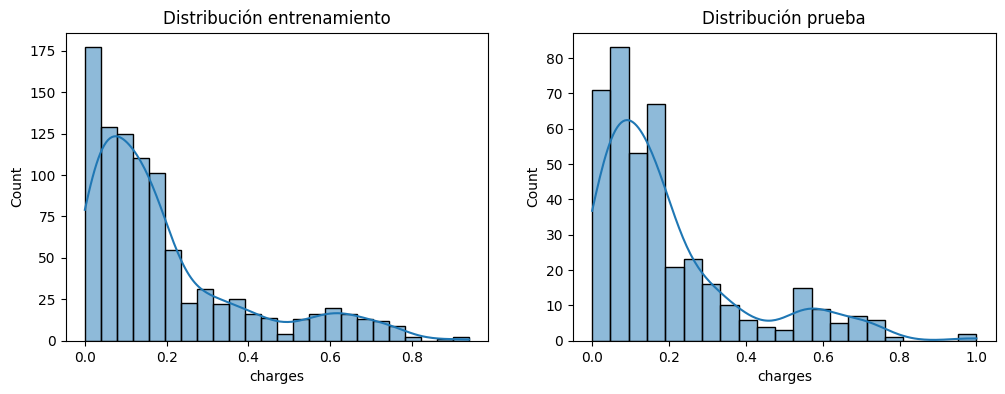

Resultados con HuberRegressor:
MAE : 0.05
MSE : 0.01
R2  : 0.68
MAPE: 45.41%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=123
)

print(f'Tamaño entrenamiento: {X_train.shape}, {y_train.shape}')
print(f'Tamaño prueba: {X_test.shape}, {y_test.shape}')

# Graficar distribución de y
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sb.histplot(y_train, ax=ax[0], kde=True)
ax[0].set_title("Distribución entrenamiento")
sb.histplot(y_test, ax=ax[1], kde=True)
ax[1].set_title("Distribución prueba")
plt.show()

# Definir modelo Huber
huber = HuberRegressor(max_iter=1000, epsilon=1.35, alpha=0.0001)

# Crear pipeline
pipe_huber = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', huber)
])

# Entrenar
pipe_huber.fit(X_train, y_train)

# Predecir
y_pred_huber = pipe_huber.predict(X_test)

# Evaluar
mae  = mean_absolute_error(y_test, y_pred_huber)
mse  = mean_squared_error(y_test, y_pred_huber)
r2   = r2_score(y_test, y_pred_huber)
mape = np.mean(np.abs((y_test - y_pred_huber) / y_test)) * 100

print("Resultados con HuberRegressor:")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"R2  : {r2:.2f}")
print(f"MAPE: {mape:.2f}%")
